# Assignment 2 — Discrete and Continuous Probability Models

## Group members

- Bibek Chaudhary (344326)
- Samo Susa (343876)
- Sneha Koirala (345788)
- Tomas Psotka (343207)

## Table of contents

1. [Imports and display settings](#imports)
2. [Part 1 — Cooling-unit failures: a finite random variable](#part-1)
3. [Part 2 — Repeated-event count models](#part-2)
   - [Late supplier deliveries: binomial](#binomial-model)
   - [Production stoppages: Poisson](#poisson-model)
   - [Extending the model to 24 hours](#poisson-24-hours)


<a id="imports"></a>

## Imports and display settings

Only methods from Sessions 3-4 are used.


In [34]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import binom, poisson

In [35]:
# Load the two datasets used later in the assignment
data_dir = Path("data") if Path("data").exists() else Path("../data")
concrete_strength = pd.read_csv(data_dir / "assignment02_concrete_strength.csv")
service_repairs = pd.read_csv(data_dir / "assignment02_service_repairs.csv")

print("Concrete strength data:", concrete_strength.shape)
print("Service repair data:", service_repairs.shape)

Concrete strength data: (160, 2)
Service repair data: (180, 2)


<a id="part-1"></a>

## Part 1 - Cooling-unit failures: a finite random variable

### Let X be the number of cooling units that fail during a weekly maintenance window. The engineering model is

| $x$ | 0 | 1 | 2 | 3 | 4 |
|:---:|:---:|:---:|:---:|:---:|:---:|
| $P(X=x)$ | 0.58 | 0.26 | 0.10 | 0.04 | 0.02 |


### a. Verify that the table is a valid PMF, state the support, and distinguish the random variable X from an observed value  x.

The probability mass function (PMF) is defined as:

$$
p_X(x) = P(X = x)
$$

For a valid PMF, the following two conditions must hold:

**1. All probabilities must be non-negative:**

$$
p_X(x) \geq 0
$$

**2. The sum of all probabilities must equal 1:**

$$
\sum_x p_X(x) = 1
$$

We verify these conditions using Python below.

In [36]:
# Define possible values and their probabilities
x = np.array([0, 1, 2, 3, 4])
pmf = np.array([0.58, 0.26, 0.10, 0.04, 0.02])

# Verify the PMF conditions
non_negative = np.all(pmf >= 0)
total_probability = np.sum(pmf)

valid_pmf = non_negative and np.isclose(total_probability, 1)

print("All probabilities are non-negative:", non_negative)
print("Sum of probabilities:", total_probability)
print("Valid PMF:", valid_pmf)

All probabilities are non-negative: True
Sum of probabilities: 1.0
Valid PMF: True


**Checking the probability model**

Every probability is non-negative, and together they add up to 1:

$$
0.58+0.26+0.10+0.04+0.02=1.
$$

The table therefore accounts for 100% of the possible outcomes, so it is a valid probability mass function.

**Possible values of the count**

The support is the set of values that have positive probability:

$$
\operatorname{supp}(X)=\{0,1,2,3,4\}.
$$

Under this model, a weekly maintenance window can have zero, one, two, three, or four failed cooling units. Counts outside this set have probability zero.

**What do $X$ and $x$ mean?**

$X$ is the random variable: the number of cooling units that fail during a window. Before we observe the window, we do not know which value it will take. The lowercase $x$ is a particular possible or observed value of that count.

For example, if we observe two failures, we record $x=2$. The model assigns this outcome a probability of

$$
P(X=2)=0.10,
$$

which means a 10% chance of exactly two failures in a window.


### b. Construct a table containing $x$, $p_X(x)$, and $F_X(x)$. Use it to calculate $P(X=2)$, $P(X\leq 1)$, $P(X\geq 2)$, and $P(1<X\leq 3)$.

The PMF answers the question, "What is the probability of exactly this many failures?"

$$
p_X(x)=P(X=x).
$$

The cumulative distribution function (CDF) answers, "What is the probability of this many failures or fewer?"

$$
F_X(x)=P(X\leq x).
$$

We calculate the CDF as a running total of the PMF probabilities:

$$
F_X(x)=\sum_{k\leq x}p_X(k).
$$

For example, the CDF at $x=1$ includes both zero failures and one failure. The table below shows the probability of each exact count alongside the running total.


In [37]:
cdf = np.cumsum(pmf)

probability_table = pd.DataFrame({
    "x": x,
    "p_X(x)": pmf,
    "F_X(x)": cdf
})

probability_table

,x,p_X(x),F_X(x)
0,0,0.58,0.58
1,1,0.26,0.84
2,2,0.10,0.94
3,3,0.04,0.98
4,4,0.02,1.00


**Reading the table and calculating probabilities**

1. **Exactly two failures:** read the PMF entry for $x=2$.

$$
P(X=2)=p_X(2)=0.10.
$$

2. **At most one failure:** include both zero and one, which is the CDF at 1.

$$
P(X\leq 1)=F_X(1)=0.58+0.26=0.84.
$$

3. **At least two failures:** the possible counts are 2, 3, and 4. We can find their total probability by subtracting the probability of zero or one failure from 1.

$$
P(X\geq 2)=1-F_X(1)=1-0.84=0.16.
$$

4. **More than one but at most three failures:** this includes exactly 2 or 3. Subtracting $F_X(1)$ from $F_X(3)$ removes the probabilities for zero and one, leaving the two outcomes we need.

$$
P(1<X\leq 3)=F_X(3)-F_X(1)=0.98-0.84=0.14.
$$


In [38]:
p_exactly_2 = pmf[2]
p_at_most_1 = cdf[1]
p_at_least_2 = 1 - cdf[1]
p_between = cdf[3] - cdf[1]

print("P(X = 2) =", round(p_exactly_2, 4))
print("P(X <= 1) =", round(p_at_most_1, 4))
print("P(X >= 2) =", round(p_at_least_2, 4))
print("P(1 < X <= 3) =", round(p_between, 4))

P(X = 2) = 0.1
P(X <= 1) = 0.84
P(X >= 2) = 0.16
P(1 < X <= 3) = 0.14


**Interpretation**

The model puts most of the probability on weeks with few failures. There is an **84% chance of zero or one failure** in a maintenance window, leaving a **16% chance of two or more failures**. Over many comparable windows, we would expect roughly 84 out of every 100 to have at most one failure, although the actual number in any particular set of 100 will vary.

The chance of exactly two failures is **10%**. Including three failures as well raises this to **14%**, which is what $P(1<X\leq3)$ describes. The strict lower bound excludes one failure, while the upper bound includes three.


### c. Plot the PMF as a bar chart and the CDF as a step plot. Explain the meaning of the height at each value in both plots.

The PMF shows the probability of each exact number of cooling-unit failures:

$$
p_X(x)=P(X=x)
$$

The CDF shows the cumulative probability up to and including each value:

$$
F_X(x)=P(X\leq x)
$$

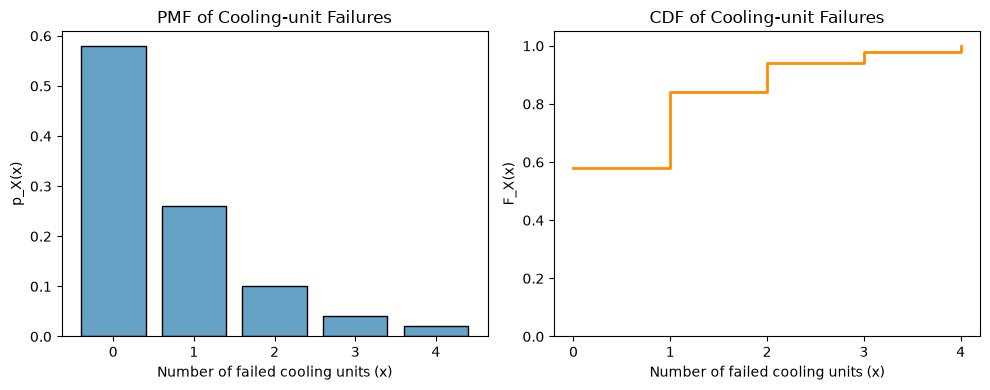

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# PMF bar chart
axes[0].bar(x, pmf, color="#66A2C6", edgecolor="black")
axes[0].set_xlabel("Number of failed cooling units (x)")
axes[0].set_ylabel("p_X(x)")
axes[0].set_title("PMF of Cooling-unit Failures")
axes[0].set_xticks(x)

# CDF step plot
axes[1].step(x, cdf, where="post", color="#FF8C00", linewidth=2)
axes[1].set_xlabel("Number of failed cooling units (x)")
axes[1].set_ylabel("F_X(x)")
axes[1].set_title("CDF of Cooling-unit Failures")
axes[1].set_xticks(x)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

**Interpreting the plots**

Both plots show the number of failed cooling units on the horizontal axis. Their vertical axes answer different questions.

In the **PMF bar chart**, each bar gives the probability of one exact count. The tallest bar is at zero, with height 0.58, so a window with no failures is the most likely individual outcome. The bar at two has height 0.10, meaning a 10% chance of exactly two failures.

In the **CDF step plot**, the height includes all counts up to that point. At two, the height is 0.94: there is a 94% chance of at most two failures, including zero and one. Similarly, $F_X(3)=0.98$ means that 98% of the model's probability is on counts of three or fewer.

The CDF stays flat between whole numbers because a failure count cannot be fractional. Each jump adds the probability of the next count. For example, it rises from 0.84 to 0.94 at $x=2$, a jump of 0.10 that matches the PMF bar at two. It reaches 1 at four because all possible counts have then been included.


### d. Calculate and interpret $E[X]$, $\mathrm{Var}(X)$, and $\mathrm{SD}(X)$.

The expected value is a weighted average of the possible failure counts. Each count is weighted by how likely it is:

$$
E[X] = \sum_x x p_X(x).
$$

The variance measures how widely the possible counts are spread around this average. It uses squared distances from the mean, weighted by their probabilities. We calculate it using the equivalent formula

$$
\mathrm{Var}(X) = E[X^2] - (E[X])^2,
$$

where the second moment is

$$
E[X^2] = \sum_x x^2 p_X(x).
$$

Taking the square root gives the standard deviation, which expresses the spread in the same units as the original failure count:

$$
\mathrm{SD}(X) = \sqrt{\mathrm{Var}(X)}.
$$


**1. Expected value**

$$
E[X] = 0(0.58)+1(0.26)+2(0.10)+3(0.04)+4(0.02)
$$

$$
E[X] = 0.66
$$

**2. Variance**

First, calculate the second moment:

$$
E[X^2] = 0^2(0.58)+1^2(0.26)+2^2(0.10)+3^2(0.04)+4^2(0.02)
$$

$$
E[X^2] = 1.34
$$

Then calculate the variance:

$$
\mathrm{Var}(X) = 1.34-(0.66)^2
$$

$$
\mathrm{Var}(X) = 0.9044
$$

**3. Standard deviation**

$$
\mathrm{SD}(X) = \sqrt{0.9044}
$$

$$
\mathrm{SD}(X) \approx 0.9510
$$

In [40]:
mean = np.sum(x * pmf)

#  E[X^2]
second_moment = np.sum(x**2 * pmf)

# variance
variance = second_moment - mean**2

# standard deviation
std_dev = np.sqrt(variance)

print("Expected value E[X] =", round(mean, 4))
print("Variance Var(X) =", round(variance, 4))
print("Standard deviation SD(X) =", round(std_dev, 4))

Expected value E[X] = 0.66
Variance Var(X) = 0.9044
Standard deviation SD(X) = 0.951


**Interpretation**

The expected value, **$E[X]=0.66$ failures per window**, describes the average over many comparable maintenance windows. For example, the model predicts an expected total of 66 failures across 100 windows. Individual windows still have whole-number counts, and a particular set of 100 windows could have a different total. Zero remains the most likely count in a single window.

The variance is **$\mathrm{Var}(X)=0.9044$ failures squared**. Squaring the distances from the mean makes larger departures contribute more to this measure of spread.

The standard deviation is **$\mathrm{SD}(X)\approx0.9510$ failures**. It puts the spread back into an easier-to-read unit: about one failed unit. This gives a sense of how much counts vary around the mean; it does not set a limit on how far a particular week's count can be from 0.66.


<a id="part-2"></a>

## Part 2 — Repeated-event count models

<a id="binomial-model"></a>

### Late supplier deliveries: binomial

Let $B$ be the number of late deliveries out of 30 deliveries. We model

$$
B \sim \operatorname{Bin}(30, 0.12).
$$

A single **Bernoulli trial** is one delivery: it is either late or not late. The binomial model counts how many of the fixed 30 deliveries are late.

The model uses four assumptions:

- the number of deliveries is fixed at $n=30$;
- each delivery is either late or not late;
- every delivery has the same probability $p=0.12$ of being late;
- the deliveries are independent, so knowing whether one is late does not change the probability for another.

Independence is an idealisation. For example, bad weather or a shared supplier problem could delay several deliveries together. The calculations below describe what we would expect when the stated assumptions are reasonable.


In [41]:
# Binomial model for late deliveries
n_deliveries = 30
p_late = 0.12

B = binom(n=n_deliveries, p=p_late)

p_b_eq_3 = B.pmf(3)
p_b_le_4 = B.cdf(4)

# sf(4) = P(B > 4), which is the same as P(B >= 5)
p_b_ge_5 = B.sf(4)

print(f"P(B = 3)  = {p_b_eq_3:.4f}")
print(f"P(B <= 4) = {p_b_le_4:.4f}")
print(f"P(B >= 5) = {p_b_ge_5:.4f}")

P(B = 3)  = 0.2224
P(B <= 4) = 0.7118
P(B >= 5) = 0.2882


For exactly three late deliveries, the binomial formula gives

$$
P(B=3)=\binom{30}{3}(0.12)^3(1-0.12)^{30-3}.
$$

The factor $(0.12)^3(0.88)^{27}$ is the probability of one particular arrangement of three late deliveries and 27 deliveries that are not late. There are

$$
\binom{30}{3}=4060
$$

different ways to choose which three deliveries are late. Multiplying by this number includes all the possible arrangements:

$$
P(B=3)=\binom{30}{3}(0.12)^3(0.88)^{27}\approx0.2224.
$$

The calculated probabilities have the following meanings:

- $P(B=3)\approx0.2224$: there is about a **22.24%** chance that exactly three of the 30 deliveries are late.
- $P(B\leq4)\approx0.7118$: there is about a **71.18%** chance that at most four are late. This includes zero, one, two, three, or four late deliveries.
- $P(B\geq5)\approx0.2882$: there is about a **28.82%** chance that five or more are late.

For example, across 100 comparable sets of 30 deliveries, we would expect about 29 sets to have five or more late deliveries. The actual number would vary.

The survival function `B.sf(k)` gives $P(B>k)$. Because the count is an integer, five or more means greater than four:

$$
P(B\geq5)=P(B>4)=\operatorname{sf}(4)=1-P(B\leq4).
$$

This is why the code uses `B.sf(4)`; `B.sf(5)` would leave out the case of exactly five late deliveries.


In [42]:
# Mean and standard deviation of a binomial random variable
binomial_mean = n_deliveries * p_late
binomial_sd = np.sqrt(n_deliveries * p_late * (1 - p_late))

print(f"Mean = {binomial_mean:.2f}")
print(f"Standard deviation = {binomial_sd:.4f}")

Mean = 3.60
Standard deviation = 1.7799


For a binomial random variable, the mean and standard deviation are

$$
E[B]=np=30(0.12)=3.6
$$

and

$$
\operatorname{SD}(B)=\sqrt{np(1-p)}=\sqrt{30(0.12)(0.88)}\approx1.7799.
$$

The mean of **3.6 late deliveries** is the average we would expect over many comparable sets of 30 deliveries. For example, across 100 such sets, the expected total is 360 late deliveries. Each individual set still has a whole number of late deliveries, and the actual total may differ from 360.

The standard deviation of about **1.78 deliveries** describes how much the number of late deliveries varies around the mean from one set to another. It is a measure of spread in the same units as the count, not a fixed limit on how far a particular result can be from 3.6.


<a id="poisson-model"></a>

### Production stoppages: Poisson

Here we count events during a fixed amount of time. Let $Y$ be the number of short production stoppages during one 8-hour shift. The stated average is 1.6 stoppages per shift, so we use

$$
Y\sim\operatorname{Poisson}(\lambda=1.6).
$$

The binomial model above starts with a fixed number of deliveries. The Poisson model starts with a fixed observation period and counts how many stoppages occur within it.

For this model:

- $\lambda=1.6$ is the expected number of stoppages in one 8-hour shift;
- the support is $\{0,1,2,\ldots\}$, since the count must be a non-negative integer;
- the mean is $E[Y]=\lambda=1.6$ stoppages per shift;
- the variance is $\operatorname{Var}(Y)=\lambda=1.6$.

The mean and variance have the same numerical value in a Poisson model, although the variance is measured in stoppages squared. The mean of 1.6 is an average across many shifts; one shift can have zero, one, two, or more stoppages. The Poisson model has no fixed upper limit on the count, although large counts become increasingly unlikely.

The probability mass function gives the probability of exactly $k$ stoppages:

$$
P(Y=k)=\frac{e^{-\lambda}\lambda^k}{k!}.
$$


In [43]:
# Poisson model for one 8-hour shift
mu_shift = 1.6
Y = poisson(mu=mu_shift)

p_y_eq_0 = Y.pmf(0)

# sf(2) = P(Y > 2) = P(Y >= 3)
p_y_ge_3 = Y.sf(2)

print(f"P(Y = 0)  = {p_y_eq_0:.4f}")
print(f"P(Y >= 3) = {p_y_ge_3:.4f}")
print(f"Mean       = {Y.mean():.2f}")
print(f"Variance   = {Y.var():.2f}")

P(Y = 0)  = 0.2019
P(Y >= 3) = 0.2166
Mean       = 1.60
Variance   = 1.60


For one 8-hour shift,

$$
P(Y=0)\approx0.2019.
$$

This gives about a **20.19%** chance of a shift with no stoppages. Across 100 comparable shifts, we would expect about 20 to have no stoppages, with variation in the actual number.

Also,

$$
P(Y\geq3)\approx0.2166.
$$

There is therefore about a **21.66%** chance of at least three stoppages in one shift. This includes three, four, five, and all higher counts; it is not just the probability of exactly three.

The code uses `Y.sf(2)` because the survival function counts values strictly greater than its input:

$$
P(Y\geq3)=P(Y>2)=1-P(Y\leq2).
$$

Subtracting the probabilities of zero, one, or two stoppages from 1 leaves the probability of three or more.


<a id="poisson-24-hours"></a>

#### Extending the model to 24 hours

Twenty-four hours contains three 8-hour periods. If the stoppage rate stays constant and the Poisson assumptions continue to hold, the expected count scales with the length of the observation period:

$$
\lambda_{24}=1.6\left(\frac{24}{8}\right)=4.8.
$$

The corresponding model is

$$
Y_{24}\sim\operatorname{Poisson}(4.8).
$$

This means an average of **4.8 stoppages per 24-hour period** over many such periods. We multiply the expected count by three because we observe production for three times as long. We then calculate the probability using the new Poisson parameter; the probability itself is not multiplied by three.


In [44]:
mu_24_hours = mu_shift * (24 / 8)
Y_24 = poisson(mu=mu_24_hours)

p_24_ge_3 = Y_24.sf(2)

print(f"Expected stoppages in 24 hours = {mu_24_hours:.2f}")
print(f"P(at least 3 stoppages in 24 hours) = {p_24_ge_3:.4f}")

Expected stoppages in 24 hours = 4.80
P(at least 3 stoppages in 24 hours) = 0.8575


The probability of at least three stoppages in 24 hours is

$$
P(Y_{24}\geq3)\approx0.8575.
$$

This is about **85.75%**. Across 100 comparable 24-hour periods, we would expect roughly 86 periods to have three or more stoppages, although the actual number would vary. As with the 8-hour calculation, `sf(2)` includes every count from three upwards.

The probability rises from about **21.66% over 8 hours** to **85.75% over 24 hours** because the longer period gives more time for stoppages to accumulate while the threshold stays at three. The expected count increases from 1.6 to 4.8.

This result depends on the Poisson assumptions remaining reasonable over the full 24 hours:

- **Stable rate:** the average number of stoppages per hour stays constant. Different workloads or operating conditions on day, evening, and night shifts could make this assumption less realistic.
- **Independence:** counts in separate, non-overlapping periods are independent. A continuing machine fault that causes several stoppages close together could violate this assumption.
